Project 5.19: The Classical Helium Atom <br>
Simulation and Modeling

**Abstract** <br>
The helium atom provides one of the simplest examples of a three-body problem in physics. By treating the two electrons classically and fixing the heavy nucleus at the origin, we reduce the system to a set of coupled ODEs governing the electron positions and velocities in two dimensions. We integrate these equations using the adaptive RK45 method and investigate the variety of orbital behaviors the system can exhibit. In particular, we examine the sensitivity of the ionization time to initial conditions and find evidence of self-similar, fractal-like structure characteristic of chaotic dynamics.

**Introduction** <br>
The classical helium atom consists of a nucleus with charge $Z=2$ and two electrons, each with unit mass and unit charge. If we ignore the small motion of the heavy nucleus, we can fix it at the origin and write the equations of motion for each electron. Each electron is attracted to the nucleus and repelled by the other electron. In atomic units where the electron mass and charge are both unity, the accelerations are:

$$\mathbf{a}_1 = -\frac{2\,\mathbf{r}_1}{r_1^3} + \frac{\mathbf{r}_1 - \mathbf{r}_2}{r_{12}^3}$$

$$\mathbf{a}_2 = -\frac{2\,\mathbf{r}_2}{r_2^3} + \frac{\mathbf{r}_2 - \mathbf{r}_1}{r_{12}^3}$$

where $\mathbf{r}_1$ and $\mathbf{r}_2$ are the position vectors of the two electrons measured from the nucleus, and $r_{12} = |\mathbf{r}_1 - \mathbf{r}_2|$ is the distance between them. The first term in each equation is the Coulomb attraction to the $Z=2$ nucleus, and the second term is the electron-electron repulsion. The force between two unit charges separated by distance $r$ is $|F| = 1/r^2$, which differs from gravitational in that the inter-body force is repulsive rather than attractive.

We restrict the problem to two dimensions for simplicity, giving each electron two position and two velocity components. The full state vector is therefore 8-dimensional: $[x_1, y_1, x_2, y_2, v_{x1}, v_{y1}, v_{x2}, v_{y2}]$. We investigate a range of initial conditions that produce qualitatively different behavior, including planetary-like orbits, braiding patterns, complex trajectories, and chaotic autoionization.

**Methods** <br>
Because the electrons can pass very close to the nucleus, their accelerations can become extremely large, requiring very small time steps during close encounters but allowing larger steps when the electrons are far apart. A fixed time step would either be too slow (if chosen small enough for close passages) or inaccurate (if chosen large for efficiency). This makes an adaptive step size algorithm essential.

So we use the RK45 method, with both absolute and relative tolerances set to $10^{-9}$ and an initial step size of $\Delta t = 0.001$ as specified in the problem.

The implementation of this solver is contained in `ode.py`. For part (d), where we need to run many simulations with early termination upon ionization, we wrap `solve_ode_rk45` in a function that integrates in chunks and checks for ionization after each chunk, avoiding the need to store a massive trajectory array for each run.

To verify that our integration is correct, we monitor two conserved quantities. The total energy of the system is:

$$E = \frac{1}{2}(v_1^2 + v_2^2) - \frac{2}{r_1} - \frac{2}{r_2} + \frac{1}{r_{12}}$$

and the total $z$-component of angular momentum (the only component in 2D) is:

$$L_z = (x_1 v_{y1} - y_1 v_{x1}) + (x_2 v_{y2} - y_2 v_{x2})$$

Both should remain constant throughout the integration if the solver is working correctly. We check these for every simulation in parts (a)-(c) to ensure accuracy before proceeding to the computationally intensive scans in part (d).

We begin by defining the derivative function and our conservation diagnostics.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from ode import solve_ode_rk45
%matplotlib inline

In [49]:
def helium_derivs(t, y, p):
    """
    Derivatives for the 2D classical helium atom.
    State vector: [x1, y1, x2, y2, vx1, vy1, vx2, vy2]
    Returns:      [vx1, vy1, vx2, vy2, ax1, ay1, ax2, ay2]
    """
    x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y

    r1_vec = np.array([x1, y1])
    r2_vec = np.array([x2, y2])
    r12_vec = r1_vec - r2_vec

    r1 = np.linalg.norm(r1_vec)
    r2 = np.linalg.norm(r2_vec)
    r12 = np.linalg.norm(r12_vec)

    # Eq 5.33
    a1 = -2.0 * r1_vec / r1**3 + r12_vec / r12**3
    a2 = -2.0 * r2_vec / r2**3 - r12_vec / r12**3

    return np.array([vx1, vy1, vx2, vy2, a1[0], a1[1], a2[0], a2[1]])


def total_energy(y_array):
    """Compute total energy (KE + PE) at each time step."""
    E = np.zeros(len(y_array))
    for i in range(len(y_array)):
        x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y_array[i]
        r1 = np.sqrt(x1**2 + y1**2)
        r2 = np.sqrt(x2**2 + y2**2)
        r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        KE = 0.5 * (vx1**2 + vy1**2 + vx2**2 + vy2**2)
        PE = -2.0/r1 - 2.0/r2 + 1.0/r12
        E[i] = KE + PE
    return E


def total_angular_momentum(y_array):
    """Compute total L_z at each time step (2D: only z-component)."""
    L = np.zeros(len(y_array))
    for i in range(len(y_array)):
        x1, y1, x2, y2, vx1, vy1, vx2, vy2 = y_array[i]
        L[i] = (x1*vy1 - y1*vx1) + (x2*vy2 - y2*vx2)
    return L


def electron_distances(y_array):
    """Compute r1, r2, r12 at each time step."""
    r1 = np.sqrt(y_array[:, 0]**2 + y_array[:, 1]**2)
    r2 = np.sqrt(y_array[:, 2]**2 + y_array[:, 3]**2)
    r12 = np.sqrt((y_array[:, 0] - y_array[:, 2])**2 + (y_array[:, 1] - y_array[:, 3])**2)
    return r1, r2, r12

p = {}  # empty parameter dict required by my implementation of solve_ode_rk45

**Analysis**

**(a) Basic Simulation** <br>
We simulate the helium atom with initial conditions $\mathbf{r}_1 = (2,0)$, $\mathbf{r}_2 = (-1,0)$, $\mathbf{v}_1 = (0, 0.95)$, and $\mathbf{v}_2 = (0, -1)$ with $\Delta t = 0.001$. These initial conditions place the two electrons on opposite sides of the nucleus with opposing velocities, similar to a mini-solar system configuration. We run the simulation to $t = 50$ and check both energy and angular momentum conservation.

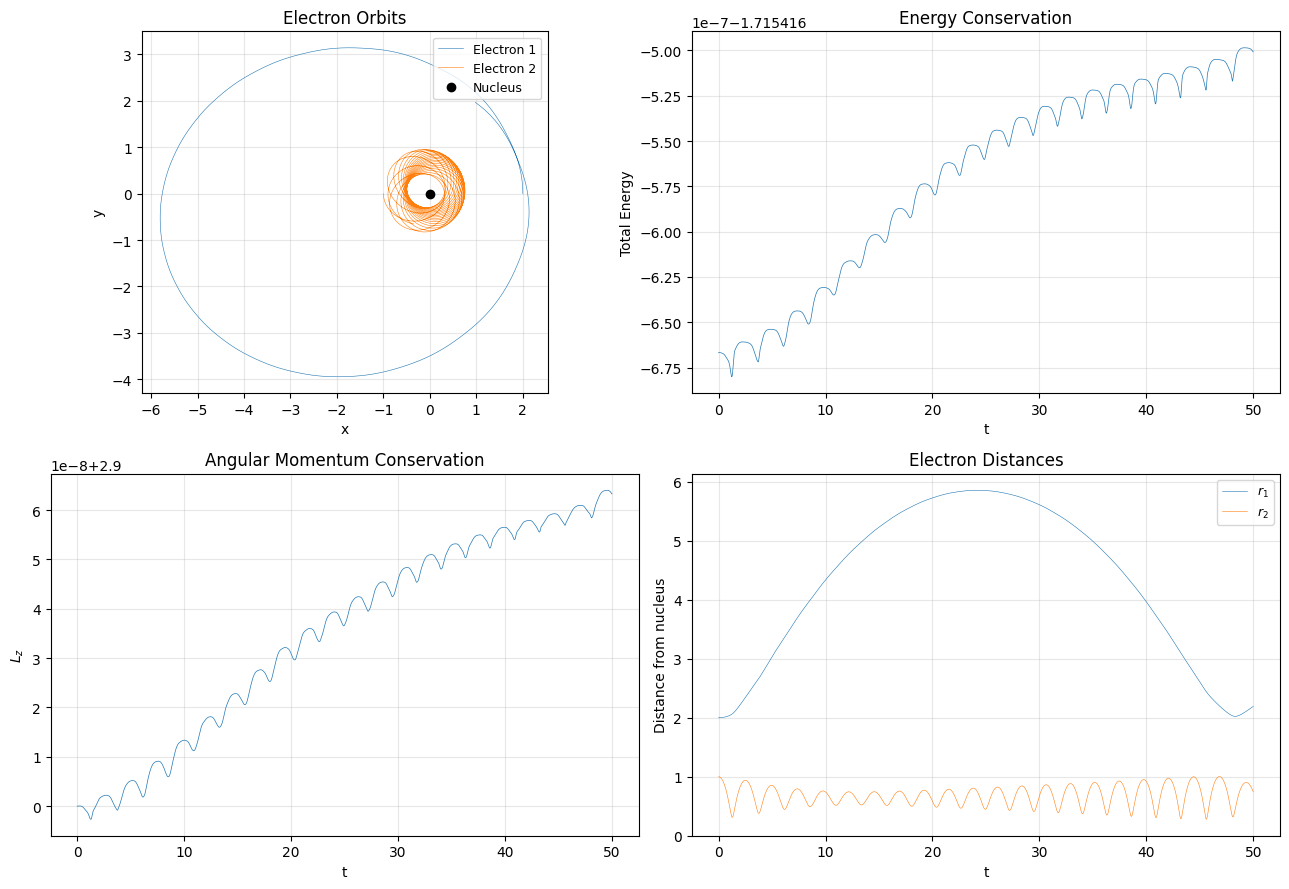

Energy:  initial = -1.715417, final = -1.715417, relative change = 9.67e-08
L_z:     initial = 2.900000, max deviation = 6.40e-08
Adaptive steps taken: 2059


In [50]:
y0_a = [2.0, 0.0, -1.0, 0.0, 0.0, 0.95, 0.0, -1.0]
t_a, y_a = solve_ode_rk45(helium_derivs, [0, 50], y0_a, p, h_init=0.001)

E_a = total_energy(y_a)
L_a = total_angular_momentum(y_a)
r1_a, r2_a, r12_a = electron_distances(y_a)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Orbits
axes[0, 0].plot(y_a[:, 0], y_a[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
axes[0, 0].plot(y_a[:, 2], y_a[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
axes[0, 0].plot(0, 0, 'ko', ms=6, label='Nucleus')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('Electron Orbits')
axes[0, 0].legend(fontsize=9)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, alpha=0.3)

# Energy
axes[0, 1].plot(t_a, E_a, lw=0.5)
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel('Total Energy')
axes[0, 1].set_title('Energy Conservation')
axes[0, 1].grid(True, alpha=0.3)

# Angular momentum
axes[1, 0].plot(t_a, L_a, lw=0.5)
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('$L_z$')
axes[1, 0].set_title('Angular Momentum Conservation')
axes[1, 0].grid(True, alpha=0.3)

# Distance from nucleus
axes[1, 1].plot(t_a, r1_a, lw=0.4, label='$r_1$', color='tab:blue')
axes[1, 1].plot(t_a, r2_a, lw=0.4, label='$r_2$', color='tab:orange')
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('Distance from nucleus')
axes[1, 1].set_title('Electron Distances')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Energy:  initial = {E_a[0]:.6f}, final = {E_a[-1]:.6f}, "
      f"relative change = {abs((E_a[-1]-E_a[0])/E_a[0]):.2e}")
print(f"L_z:     initial = {L_a[0]:.6f}, max deviation = {np.max(np.abs(L_a - L_a[0])):.2e}")
print(f"Adaptive steps taken: {len(t_a)}")

The orbits resemble a mini-solar system: electron 1 follows a wide orbit while electron 2 stays close to the nucleus. The distance plot confirms this quantitatively, electron 1 oscillates between roughly $1$ and $6$ units from the nucleus while electron 2 stays within about $1$ unit. Energy is conserved to a relative change on the order of $10^{-8}$, and angular momentum to $\sim 10^{-9}$, which confirms that the adaptive RK45 solver is working correctly with the chosen tolerances.

**(b) Braiding Orbits and Autoionization** <br>
The initial condition $\mathbf{r}_1 = (1.4,0)$, $\mathbf{r}_2 = (-1,0)$, $\mathbf{v}_1 = (0, 0.86)$, $\mathbf{v}_2 = (0, -1)$ is reported to produce braiding orbits. We simulate this and then perturb $v_{1y}$ by $\pm 0.02$ to observe how small changes destroy the stable pattern and lead to autoionization, where one electron gains enough energy to escape the atom.

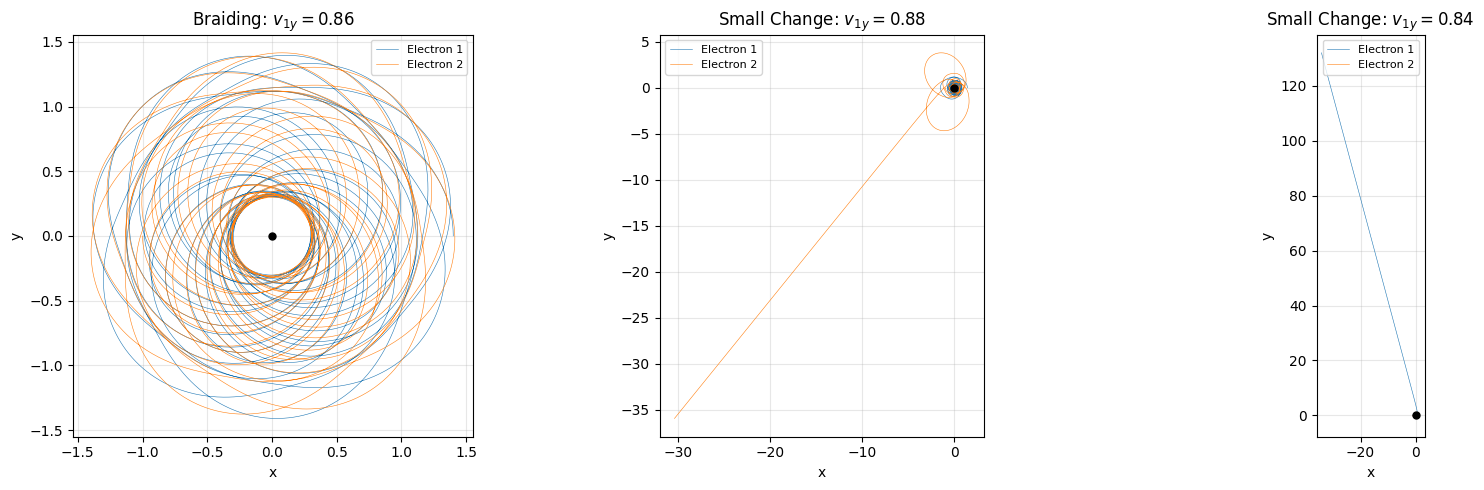

In [51]:
# Braiding orbit
y0_b = [1.4, 0.0, -1.0, 0.0, 0.0, 0.86, 0.0, -1.0]
t_b, y_b = solve_ode_rk45(helium_derivs, [0, 100], y0_b, p, h_init=0.001)

# Changed cases
y0_b_up = [1.4, 0.0, -1.0, 0.0, 0.0, 0.88, 0.0, -1.0]
t_b_up, y_b_up = solve_ode_rk45(helium_derivs, [0, 100], y0_b_up, p, h_init=0.001)

y0_b_dn = [1.4, 0.0, -1.0, 0.0, 0.0, 0.84, 0.0, -1.0]
t_b_dn, y_b_dn = solve_ode_rk45(helium_derivs, [0, 100], y0_b_dn, p, h_init=0.001)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, ydata, title in zip(axes,
        [y_b, y_b_up, y_b_dn],
        ['Braiding: $v_{1y}=0.86$',
         'Small Change: $v_{1y}=0.88$',
         'Small Change: $v_{1y}=0.84$']):
    ax.plot(ydata[:, 0], ydata[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
    ax.plot(ydata[:, 2], ydata[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
    ax.plot(0, 0, 'ko', ms=5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The normal initial condition produces a striking braiding pattern where both electrons weave around the nucleus in interleaved loops. Even a change of $\pm 0.02$ in $v_{1y}$ is enough to destroy this pattern and lead to autoionization. The escape trajectories dominate the plot making them hard to properly analyze, so lets instead examine the distance from the nucleus over time to better visualize when and how ionization occurs.

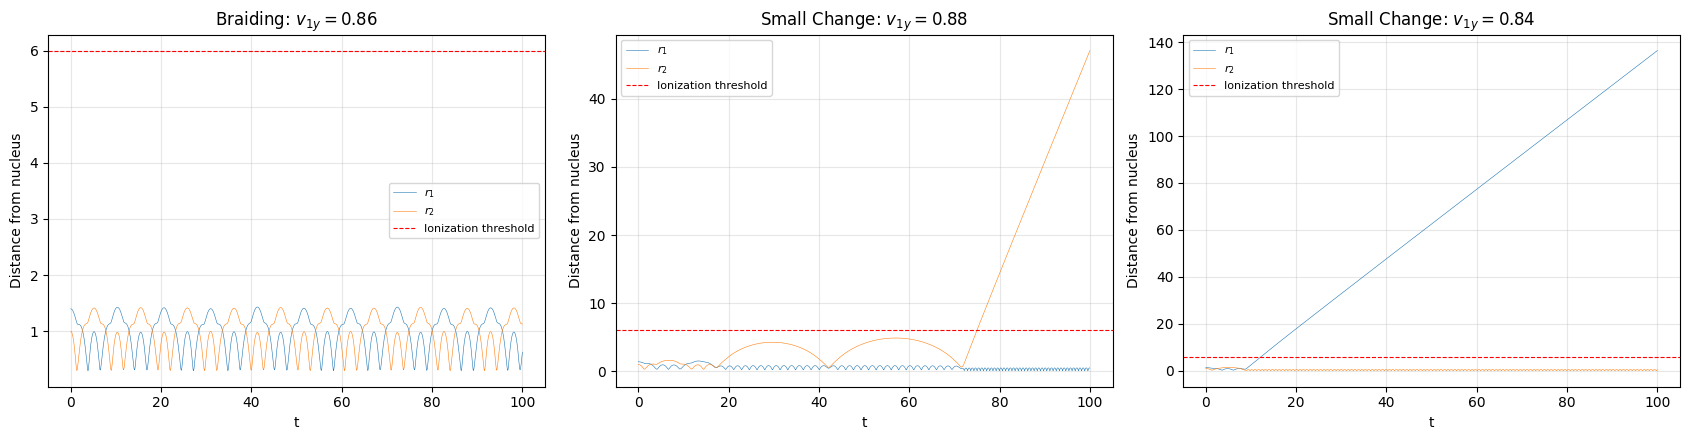

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, tdata, ydata, title in zip(axes,
        [t_b, t_b_up, t_b_dn],
        [y_b, y_b_up, y_b_dn],
        ['Braiding: $v_{1y}=0.86$',
         'Small Change: $v_{1y}=0.88$',
         'Small Change: $v_{1y}=0.84$']):
    r1, r2, _ = electron_distances(ydata)
    ax.plot(tdata, r1, lw=0.4, label='$r_1$', color='tab:blue')
    ax.plot(tdata, r2, lw=0.4, label='$r_2$', color='tab:orange')
    ax.axhline(6, color='red', ls='--', lw=0.8, label='Ionization threshold')
    ax.set_xlabel('t')
    ax.set_ylabel('Distance from nucleus')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The distance plots show the braiding orbit has both electrons oscillating at comparable distances from the nucleus, neither dominates, and both remain bounded. In the cases with a small change, one electron suddenly gains distance and escapes, while the other falls closer to the nucleus (becoming more tightly bound to conserve energy). This is the autoionization mechanism: a close three-body encounter transfers enough energy to one electron for it to escape.

To explore this sensitivity more in a much more insightful way, we can sweep $v_{1y}$ over a range and measure how long the atom survives before ionization.

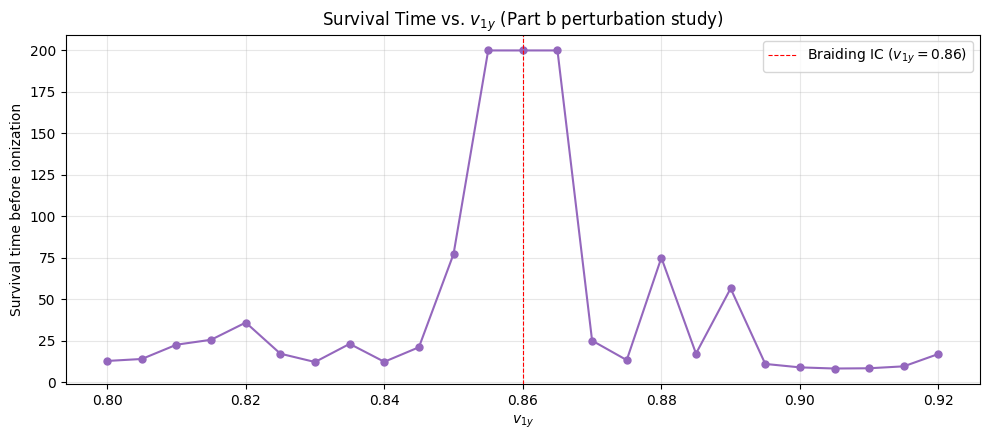

In [53]:
# Systematic perturbation sweep
v1y_sweep = np.arange(0.80, 0.921, 0.005)
survival_times = np.zeros(len(v1y_sweep))

for i, v1y in enumerate(v1y_sweep):
    y0_test = [1.4, 0.0, -1.0, 0.0, 0.0, v1y, 0.0, -1.0]
    t_test, y_test = solve_ode_rk45(helium_derivs, [0, 200], y0_test, p, h_init=0.001)
    r1_test, r2_test, _ = electron_distances(y_test)
    ionized = np.where((r1_test > 6) | (r2_test > 6))[0]
    survival_times[i] = t_test[ionized[0]] if len(ionized) > 0 else 200.0

plt.figure(figsize=(10, 4.5))
plt.plot(v1y_sweep, survival_times, 'o-', ms=5, color='tab:purple')
plt.axvline(0.86, color='red', ls='--', lw=0.8, label='Braiding IC ($v_{1y}=0.86$)')
plt.xlabel(r'$v_{1y}$')
plt.ylabel('Survival time before ionization')
plt.title(r'Survival Time vs. $v_{1y}$ (Part b perturbation study)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The braiding initial condition at $v_{1y} = 0.86$ sits near a peak of survival time, a narrow area of stability surrounded by conditions that ionize quickly. This is consistent with the chaotic nature of the three-body problem: the braiding orbit is a special, marginally stable configuration, and small changes push the system into chaotic territory where ionization is inevitable.

**(c) Complex Orbits and Angular Momentum** <br>
We investigate two more initial conditions that produce complex orbits and check whether the total angular momentum is conserved.

First: $\mathbf{r}_1 = (3,0)$, $\mathbf{r}_2 = (1,0)$, $\mathbf{v}_1 = (0, 0.4)$, $\mathbf{v}_2 = (0, -1)$. This has $L_z = 3(0.4) + 1(-1) = 0.2$.  <br>
Second: $\mathbf{r}_1 = (2.5,0)$, $\mathbf{r}_2 = (1,0)$, $\mathbf{v}_1 = (0, 0.4)$, $\mathbf{v}_2 = (0, -1)$. This has $L_z = 2.5(0.4) + 1(-1) = 0.0$.

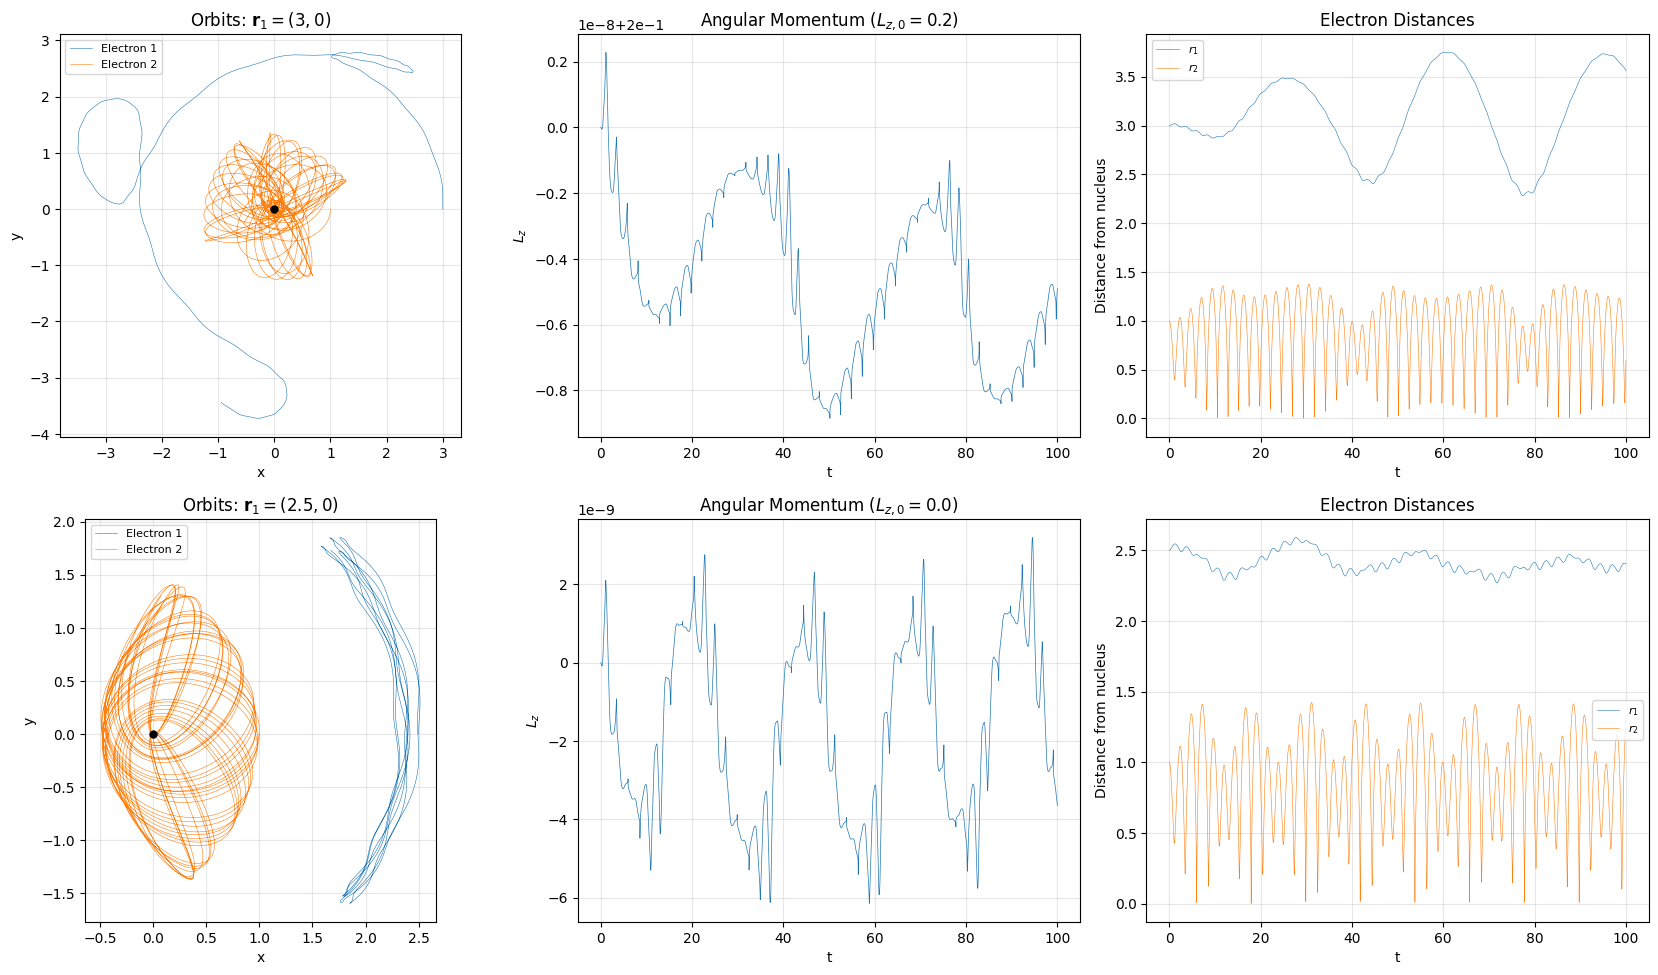

IC 1: L_z: initial = 0.200000, max deviation = 8.85e-09
IC 2: L_z: initial = 0.000000, max deviation = 6.15e-09
IC 1: Energy: initial = -1.586667, relative change = 1.64e-06
IC 2: Energy: initial = -1.553333, relative change = 3.42e-08


In [54]:
y0_c1 = [3.0, 0.0, 1.0, 0.0, 0.0, 0.4, 0.0, -1.0]
t_c1, y_c1 = solve_ode_rk45(helium_derivs, [0, 100], y0_c1, p, h_init=0.001)

y0_c2 = [2.5, 0.0, 1.0, 0.0, 0.0, 0.4, 0.0, -1.0]
t_c2, y_c2 = solve_ode_rk45(helium_derivs, [0, 100], y0_c2, p, h_init=0.001)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# IC 1
axes[0, 0].plot(y_c1[:, 0], y_c1[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
axes[0, 0].plot(y_c1[:, 2], y_c1[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
axes[0, 0].plot(0, 0, 'ko', ms=5)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('Orbits: $\\mathbf{r}_1=(3,0)$')
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, alpha=0.3)

L_c1 = total_angular_momentum(y_c1)
axes[0, 1].plot(t_c1, L_c1, lw=0.5)
axes[0, 1].set_xlabel('t')
axes[0, 1].set_ylabel('$L_z$')
axes[0, 1].set_title('Angular Momentum ($L_{z,0}=0.2$)')
axes[0, 1].grid(True, alpha=0.3)

r1_c1, r2_c1, _ = electron_distances(y_c1)
axes[0, 2].plot(t_c1, r1_c1, lw=0.4, label='$r_1$', color='tab:blue')
axes[0, 2].plot(t_c1, r2_c1, lw=0.4, label='$r_2$', color='tab:orange')
axes[0, 2].set_xlabel('t')
axes[0, 2].set_ylabel('Distance from nucleus')
axes[0, 2].set_title('Electron Distances')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# IC 2
axes[1, 0].plot(y_c2[:, 0], y_c2[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
axes[1, 0].plot(y_c2[:, 2], y_c2[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
axes[1, 0].plot(0, 0, 'ko', ms=5)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('y')
axes[1, 0].set_title('Orbits: $\\mathbf{r}_1=(2.5,0)$')
axes[1, 0].legend(fontsize=8)
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, alpha=0.3)

L_c2 = total_angular_momentum(y_c2)
axes[1, 1].plot(t_c2, L_c2, lw=0.5)
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('$L_z$')
axes[1, 1].set_title('Angular Momentum ($L_{z,0}=0.0$)')
axes[1, 1].grid(True, alpha=0.3)

r1_c2, r2_c2, _ = electron_distances(y_c2)
axes[1, 2].plot(t_c2, r1_c2, lw=0.4, label='$r_1$', color='tab:blue')
axes[1, 2].plot(t_c2, r2_c2, lw=0.4, label='$r_2$', color='tab:orange')
axes[1, 2].set_xlabel('t')
axes[1, 2].set_ylabel('Distance from nucleus')
axes[1, 2].set_title('Electron Distances')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"IC 1: L_z: initial = {L_c1[0]:.6f}, max deviation = {np.max(np.abs(L_c1 - L_c1[0])):.2e}")
print(f"IC 2: L_z: initial = {L_c2[0]:.6f}, max deviation = {np.max(np.abs(L_c2 - L_c2[0])):.2e}")

E_c1 = total_energy(y_c1)
E_c2 = total_energy(y_c2)
print(f"IC 1: Energy: initial = {E_c1[0]:.6f}, relative change = {abs((E_c1[-1]-E_c1[0])/E_c1[0]):.2e}")
print(f"IC 2: Energy: initial = {E_c2[0]:.6f}, relative change = {abs((E_c2[-1]-E_c2[0])/E_c2[0]):.2e}")

The distance plots reveal interesting dynamics. In IC 1 ($L_z = 0.2$), electron 1 starts far from the nucleus and occasionally dips inward (around $t \approx 50$–$70$), while electron 2 remains relatively tightly bound throughout. This partial exchange, where the outer electron temporarily moves inward, is characteristic of three-body interactions. In IC 2 ($L_z = 0.0$), zero total angular momentum does not prevent complex motion, electron 2 oscillates rapidly while electron 1 drifts slowly at a larger radius. The electrons can still exchange angular momentum between themselves even though the total remains zero.

**(d) Ionization Time vs. Initial Velocity** <br>
We fix $\mathbf{r}_1 = (2,0)$, $\mathbf{r}_2 = (-1,0)$, $\mathbf{v}_2 = (0,-1)$ and vary $\mathbf{v}_1 = (v_{1x}, 0)$ from $v_{1x} = 0.6$ to $1.3$ in steps of $\Delta v = 0.02$. For each initial condition, we integrate until either electron exceeds a distance of $6$ from the nucleus (autoionization) or until $t = 2000$. We use `solve_ode_rk45`, integrating in chunks and checking for ionization after each chunk to avoid storing unnecessarily large trajectory arrays.

In [55]:
def ionization_time(v1x, t_max=2000.0, r_max=6.0, chunk=50.0, h_init=0.001):
    """
    Integrate the helium atom using rk45 and return the 
    time at which ionization occurs (either electron exceeds r_max from nucleus).
    Returns t_max if no ionization occurs within the time limit.
    
    We integrate in chunks to avoid storing a massive trajectory array
    for the full t_max, and check for ionization after each chunk.
    """
    y0 = [2.0, 0.0, -1.0, 0.0, v1x, 0.0, 0.0, -1.0]
    t_start = 0.0
    
    while t_start < t_max:
        t_end = min(t_start + chunk, t_max)
        t_arr, y_arr = solve_ode_rk45(helium_derivs, [t_start, t_end], y0, p, h_init=h_init)
        
        # Check each step for ionization
        r1 = np.sqrt(y_arr[:, 0]**2 + y_arr[:, 1]**2)
        r2 = np.sqrt(y_arr[:, 2]**2 + y_arr[:, 3]**2)
        ionized = np.where((r1 > r_max) | (r2 > r_max))[0]
        
        if len(ionized) > 0:
            return t_arr[ionized[0]]
        
        # Continue from where we left off
        y0 = y_arr[-1]
        t_start = t_arr[-1]
        h_init = t_arr[-1] - t_arr[-2]  # use last step size as next initial
    
    return t_max

Before running the full scan, it is helpful to visualize what a "short-lived" vs "long-lived" trajectory looks like. We pick two representative values of $v_{1x}$, one that ionizes quickly and one that survives longer, and compare their orbits and distances.

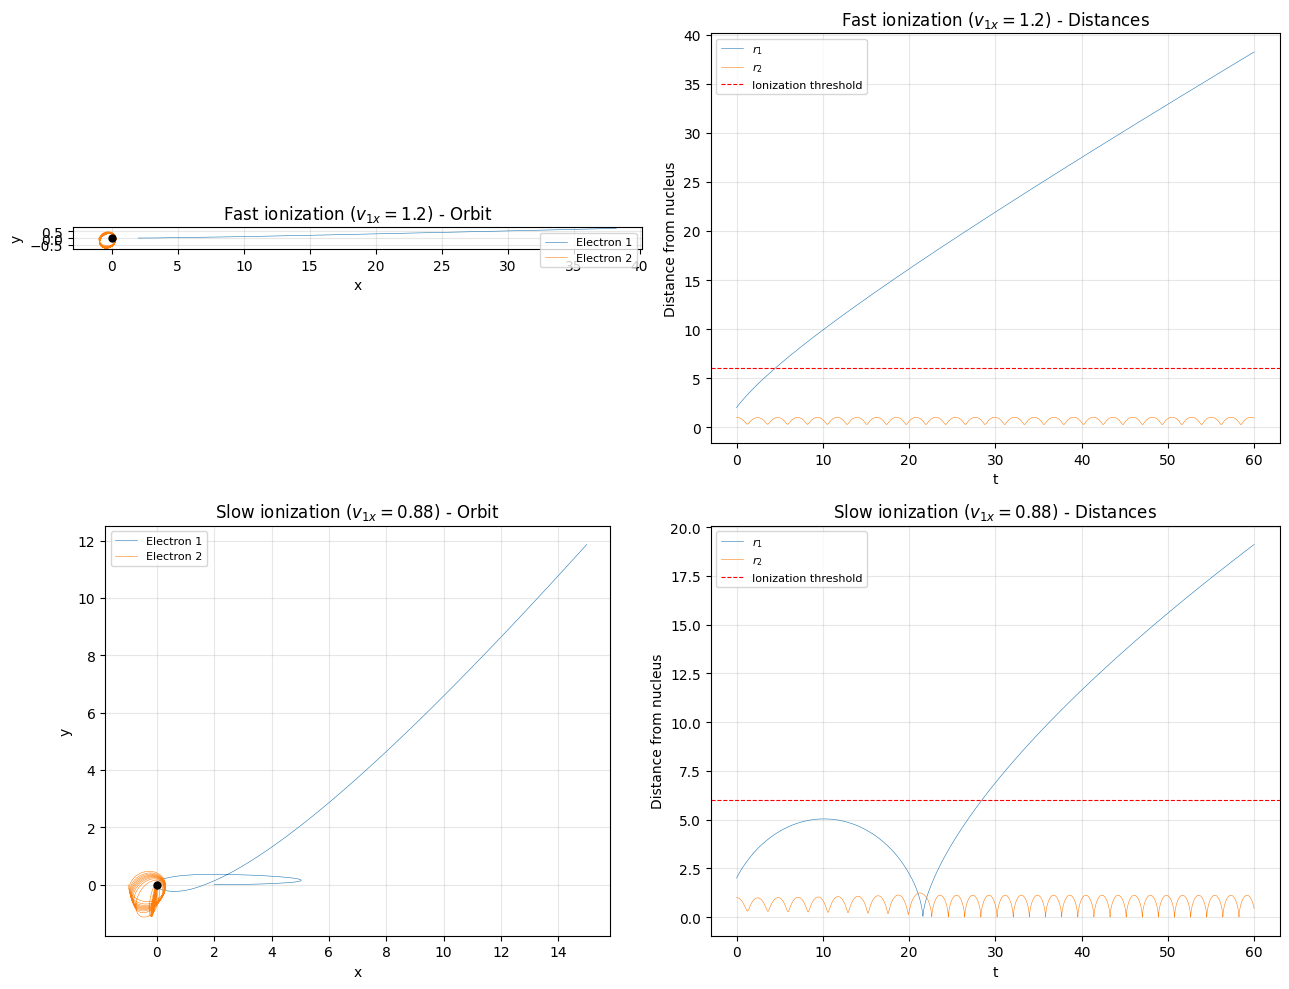

In [56]:
# Compare a fast ionization and a slow one
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, (v1x, label) in enumerate([(1.2, 'Fast ionization ($v_{1x}=1.2$)'),
                                      (0.88, 'Slow ionization ($v_{1x}=0.88$)')]):
    y0_ex = [2.0, 0.0, -1.0, 0.0, v1x, 0.0, 0.0, -1.0]
    t_ex, y_ex = solve_ode_rk45(helium_derivs, [0, 60], y0_ex, p, h_init=0.001)
    
    axes[row, 0].plot(y_ex[:, 0], y_ex[:, 1], lw=0.4, label='Electron 1', color='tab:blue')
    axes[row, 0].plot(y_ex[:, 2], y_ex[:, 3], lw=0.4, label='Electron 2', color='tab:orange')
    axes[row, 0].plot(0, 0, 'ko', ms=5)
    axes[row, 0].set_xlabel('x')
    axes[row, 0].set_ylabel('y')
    axes[row, 0].set_title(f'{label} - Orbit')
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].grid(True, alpha=0.3)
    
    r1_ex, r2_ex, _ = electron_distances(y_ex)
    axes[row, 1].plot(t_ex, r1_ex, lw=0.4, label='$r_1$', color='tab:blue')
    axes[row, 1].plot(t_ex, r2_ex, lw=0.4, label='$r_2$', color='tab:orange')
    axes[row, 1].axhline(6, color='red', ls='--', lw=0.8, label='Ionization threshold')
    axes[row, 1].set_xlabel('t')
    axes[row, 1].set_ylabel('Distance from nucleus')
    axes[row, 1].set_title(f'{label} - Distances')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With $v_{1x} = 1.2$, electron 1 has enough radial kinetic energy to escape almost immediately, it barely interacts with electron 2 before ionizing. With $v_{1x} = 0.88$, the electron is pulled back by the nucleus and enters a prolonged, chaotic interaction with electron 2 before eventually one of them escapes. This is why the ionization time is much more sensitive to $v_{1x}$ at lower velocities, the electrons have time for many complex encounters, and the outcome depends sensitively on the details.

Now we perform the coarse scan.

In [57]:
v1x_coarse = np.arange(0.6, 1.301, 0.02)
ion_coarse = np.zeros(len(v1x_coarse))

for i, v1x in enumerate(v1x_coarse):
    ion_coarse[i] = ionization_time(v1x)
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(v1x_coarse)}")

print("Coarse scan complete.")

  Completed 10/36
  Completed 20/36
  Completed 30/36
Coarse scan complete.


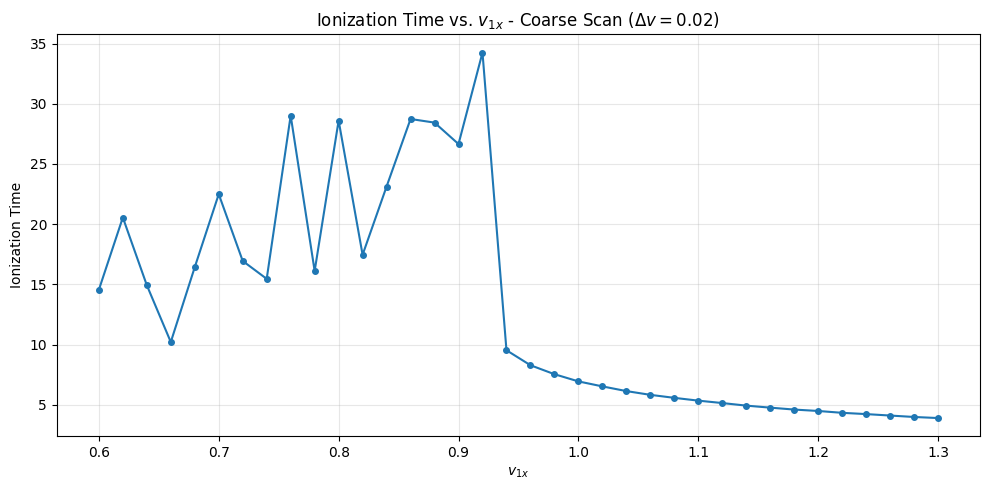

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(v1x_coarse, ion_coarse, 'o-', ms=4, color='tab:blue')
plt.xlabel(r'$v_{1x}$')
plt.ylabel('Ionization Time')
plt.title(r'Ionization Time vs. $v_{1x}$ - Coarse Scan ($\Delta v = 0.02$)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The coarse scan reveals an irregular, spiky pattern. Ionization times are generally longer for smaller $v_{1x}$ (where the electron is bound long enough for complex interactions) and drop off smoothly at higher velocities (where it escapes almost immediately). We now zoom into the region around the longest ionization time to see if the fine structure resembles the coarse structure.

In [59]:
peak_idx = np.argmax(ion_coarse)
v_center = v1x_coarse[peak_idx]
print(f"Longest ionization time: {ion_coarse[peak_idx]:.1f} at v1x = {v_center:.2f}")

v1x_fine = np.arange(v_center - 0.05, v_center + 0.051, 0.002)
ion_fine = np.zeros(len(v1x_fine))

for i, v1x in enumerate(v1x_fine):
    ion_fine[i] = ionization_time(v1x)
    if (i+1) % 10 == 0:
        print(f"  Completed {i+1}/{len(v1x_fine)}")

print("Fine scan complete.")

Longest ionization time: 34.2 at v1x = 0.92
  Completed 10/51
  Completed 20/51
  Completed 30/51
  Completed 40/51
  Completed 50/51
Fine scan complete.


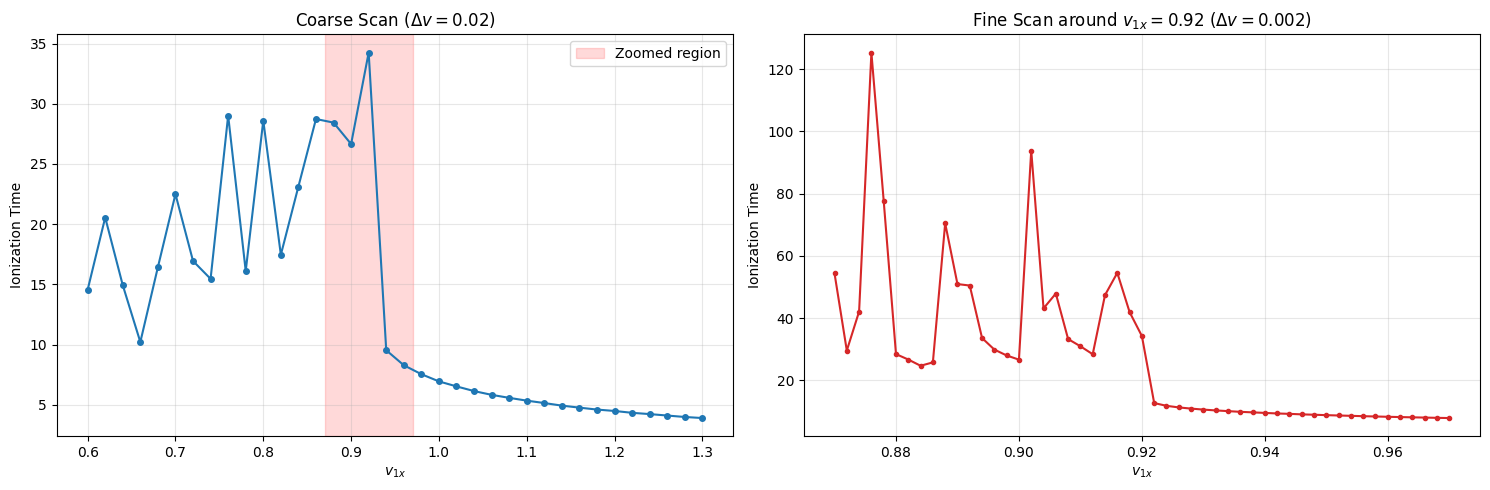

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(v1x_coarse, ion_coarse, 'o-', ms=4, color='tab:blue')
axes[0].set_xlabel(r'$v_{1x}$')
axes[0].set_ylabel('Ionization Time')
axes[0].set_title(r'Coarse Scan ($\Delta v = 0.02$)')
axes[0].axvspan(v_center - 0.05, v_center + 0.05, alpha=0.15, color='red', label='Zoomed region')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(v1x_fine, ion_fine, 'o-', ms=3, color='tab:red')
axes[1].set_xlabel(r'$v_{1x}$')
axes[1].set_ylabel('Ionization Time')
axes[1].set_title(f'Fine Scan around $v_{{1x}}={v_center:.2f}$' + r' ($\Delta v = 0.002$)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The side-by-side comparison clearly shows self-similarity: the fine scan (right) has the same qualitative spiky structure as the coarse scan (left), with new peaks appearing that were invisible at the coarser resolution. The longest ionization times in the fine scan are significantly longer than those in the coarse scan, which is expected since finer resolution can resolve the narrow peaks more precisely.

To further test the self-similar hypothesis, we perform one more zoom into the tallest peak of the fine scan.

In [61]:
peak_fine_idx = np.argmax(ion_fine)
v_center2 = v1x_fine[peak_fine_idx]
print(f"Fine scan peak: {ion_fine[peak_fine_idx]:.1f} at v1x = {v_center2:.4f}")

v1x_finer = np.arange(v_center2 - 0.005, v_center2 + 0.0051, 0.0005)
ion_finer = np.zeros(len(v1x_finer))

for i, v1x in enumerate(v1x_finer):
    ion_finer[i] = ionization_time(v1x)

print("Ultra-fine scan complete.")

Fine scan peak: 125.3 at v1x = 0.8760
Ultra-fine scan complete.


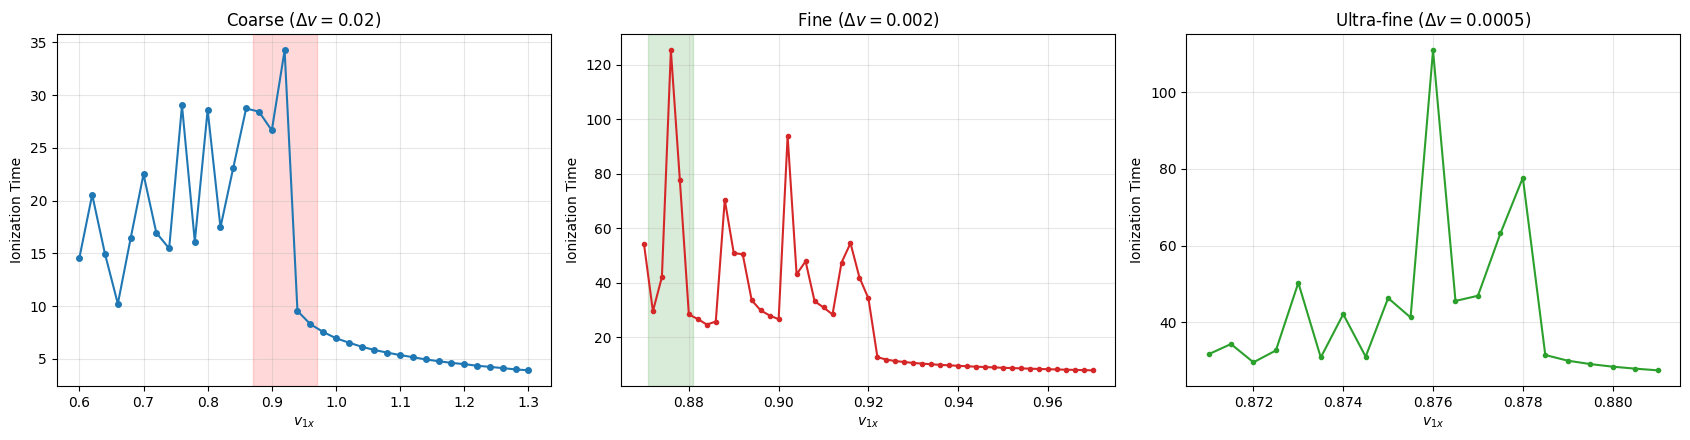

Peak ionization times - Coarse: 34.2, Fine: 125.3, Ultra-fine: 110.9


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(v1x_coarse, ion_coarse, 'o-', ms=4, color='tab:blue')
axes[0].set_xlabel(r'$v_{1x}$')
axes[0].set_ylabel('Ionization Time')
axes[0].set_title(r'Coarse ($\Delta v = 0.02$)')
axes[0].axvspan(v_center - 0.05, v_center + 0.05, alpha=0.15, color='red')
axes[0].grid(True, alpha=0.3)

axes[1].plot(v1x_fine, ion_fine, 'o-', ms=3, color='tab:red')
axes[1].set_xlabel(r'$v_{1x}$')
axes[1].set_ylabel('Ionization Time')
axes[1].set_title(f'Fine ($\\Delta v = 0.002$)')
axes[1].axvspan(v_center2 - 0.005, v_center2 + 0.005, alpha=0.15, color='green')
axes[1].grid(True, alpha=0.3)

axes[2].plot(v1x_finer, ion_finer, 'o-', ms=3, color='tab:green')
axes[2].set_xlabel(r'$v_{1x}$')
axes[2].set_ylabel('Ionization Time')
axes[2].set_title(f'Ultra-fine ($\\Delta v = 0.0005$)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peak ionization times - Coarse: {np.max(ion_coarse):.1f}, "
      f"Fine: {np.max(ion_fine):.1f}, Ultra-fine: {np.max(ion_finer):.1f}")

At all three levels of resolution, the same spiky structure appears: narrow peaks of long ionization time separated by valleys of rapid ionization. This confirms the self-similar, fractal nature of the ionization boundary. As we zoom in, the peak ionization times grow, this is because finer resolution resolves ever-narrower peaks corresponding to initial conditions that happen to thread through many close encounters before one electron finally escapes. In principle, if we continued zooming indefinitely, we would find peaks of arbitrary height, corresponding to trajectories that are arbitrarily close to a stable (but unstable in the Lyapunov sense) orbit.

**Interpretation** <br>
The classical helium atom, despite having only two electrons and a fixed nucleus, exhibits a remarkably rich variety of dynamical behaviors.

In part (a), certain initial conditions produce stable, planetary-like orbits where the two electrons remain bound on different scales. The electron distance plot revealed that electron 1 oscillates at large radii while electron 2 stays tightly bound, analogous to an inner and outer planet. Our energy and angular momentum conservation checks confirmed that the RK45 solver maintains accuracy to $\sim 10^{-8}$ in energy and $\sim 10^{-9}$ in $L_z$, which provides confidence in our results throughout the remaining parts.

In part (b), the braiding orbits demonstrated a qualitatively different mode where both electrons participate equally, weaving around the nucleus in interleaved loops. Our systematic sweep of small changes in parameters showed that this braiding configuration sits at a narrow peak or area of stability, a change of just a few percent in $v_{1y}$ leads to autoionization. The distance-vs-time plots allowed us to clearly visualize the ionization mechanism: a close three-body encounter transfers enough energy to one electron to escape, while the other falls into a tighter orbit around the nucleus.

Part (c) confirmed angular momentum conservation to the precision of our solver for two sets of complex initial conditions. The distance plots revealed interesting exchange dynamics where the electrons periodically swap roles, the outer electron moves inward while the inner electron moves outward. This exchange behavior is a hallmark of the three-body problem and does not occur in integrable two-body systems.

The most striking result was the self-similar structure found in part (d). By performing three successive levels of zoom (coarse, fine, and ultra-fine), we observed the same spiky pattern repeating at each scale, with peak ionization times growing with resolution. The smooth, low-ionization-time region at high $v_{1x}$ corresponds to the non-chaotic regime where electron 1 simply has too much radial kinetic energy to remain bound.

A source of uncertainty worth noting is that the chaotic nature of the system means that individual trajectories are not reproducible to arbitrary precision, small changes in tolerance or step size can change the exact ionization time for a given $v_{1x}$. However, the *statistical* structure (the spiky, self-similar pattern) is independent of these numerical details.